## RetentionAI — 04. Feature Engineering

**Objective:** propose new features — each one grounded in a specific
finding from `02_data_understanding.ipynb` or the EDA hypotheses (H1–H5),
never "this seems useful" — and score each with Information Value (IV)
before deciding keep or reject.

**Out of scope for this notebook** (deferred to `05_pipeline.ipynb`,
Stage 6): dropping raw columns, encoding, scaling, multicollinearity
(VIF) checks. IV is a *univariate* test — it tells you whether one feature
carries signal in isolation, not whether two features are redundant with
each other. Using it to decide what to drop would be the wrong tool for
that question.

> Runs on synthetic data in this sandbox — re-run unchanged on the real
> `data/raw/telco_churn.csv` (no code changes needed, `config.py` already
> points there). Heads up: the synthetic generator bakes in a strong
> direct tenure/contract → churn relationship, so IV for `tenure` and
> `Contract` may read as "suspiciously strong" here in a way that's an
> artifact of fake data, not real leakage. On the real dataset, an IV
> that high on a raw column *would* be worth pausing to check for
> leakage — this run is just not the case that proves it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_CSV_PATH
from src.features.iv import compute_iv, iv_summary, interpret_iv

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(RAW_CSV_PATH)

# Carrying forward Stage 3/4 decisions (not re-deciding them here)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn_numeric"] = (df["Churn"] == "Yes").astype(int)

print("Shape:", df.shape)
df.head(3)

Shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


### Candidate features, each tied to a named finding

| Feature | Source finding |
|---|---|
| `TotalAddOnServices` | H2 — individual add-ons (`TechSupport`, `OnlineSecurity`) showed a churn gap. Does the *count* of add-ons a customer has matter even more than any single one? |
| `IsNewCustomer` | H3 — the tenure/churn relationship wasn't linear; risk was front-loaded. A single correlation number can't express "the first few months are dangerous" — a binary flag can. |
| `ContractCommitmentMonths` | H1 — `Contract` is genuinely ordered (no commitment → 1yr → 2yr), but one-hot encoding throws that order away. This gives it back, specifically for models that can use an ordinal number. |
| `AvgMonthlySpend` | H4 — `MonthlyCharges` mattered. Does *average* spend over the whole relationship (`TotalCharges / tenure`) add anything `MonthlyCharges` alone doesn't already say? Flagged now: this is the one most likely to get rejected — a plausible-sounding derivation isn't evidence on its own. |

For each: build it, compute its IV, and compare against the IV of the raw
column(s) it was derived from. Keep only if it earns its place.

### Feature 1 — `TotalAddOnServices`

Sum of the 6 add-on flags (`OnlineSecurity`, `OnlineBackup`,
`DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`),
counting only actual `"Yes"` subscriptions — `"No internet service"` is
not a real "No" for this purpose (same structural-category rule from the
EDA stage), so it correctly counts as 0 either way here.

TotalAddOnServices IV: 0.1497 (medium)

Raw add-on columns for comparison:
            feature      iv                              strength
0    OnlineSecurity  0.7161  suspiciously strong -- check leakage
1       TechSupport  0.6979  suspiciously strong -- check leakage
2      OnlineBackup  0.5273  suspiciously strong -- check leakage
3  DeviceProtection  0.4984                                strong
4   StreamingMovies  0.3802                                strong
5       StreamingTV  0.3793                                strong


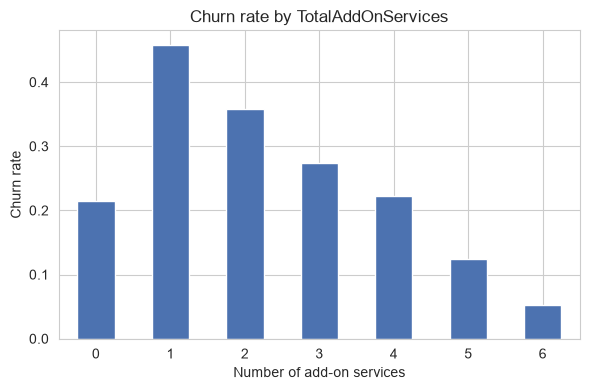

In [2]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]

df["TotalAddOnServices"] = (df[addon_cols] == "Yes").sum(axis=1)

iv_new, _ = compute_iv(df, "TotalAddOnServices", "Churn_numeric")
iv_raw = iv_summary(df, addon_cols, "Churn_numeric")

print(f"TotalAddOnServices IV: {iv_new:.4f} ({interpret_iv(iv_new)})")
print("\nRaw add-on columns for comparison:")
print(iv_raw)

fig, ax = plt.subplots(figsize=(6, 4))
df.groupby("TotalAddOnServices")["Churn_numeric"].mean().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Churn rate")
ax.set_xlabel("Number of add-on services")
ax.set_title("Churn rate by TotalAddOnServices")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Verdict:** `TotalAddOnServices` (IV = 0.1497, medium) is decisively
weaker than *every one* of the six raw columns it's built from —
`OnlineSecurity` (0.72), `TechSupport` (0.70), `OnlineBackup` (0.53),
`DeviceProtection` (0.50), `StreamingMovies` (0.38), `StreamingTV` (0.38)
all individually beat it, several by 4-5x. Likely cause: collapsing six
columns into one count merges two very different populations at count=0 —
customers with `"No internet service"` (structurally can't have add-ons)
and internet customers who simply declined every add-on. Those groups
probably have very different baseline churn, and averaging them together
is likely why the aggregate underperforms so badly. **Reject** — keep the
six raw columns individually.

### Feature 2 — `IsNewCustomer`

Binary flag for `tenure <= 6` months. Threshold choice: your Stage 4
bucketed tenure chart showed the churn rate drop was steepest in the
earliest bucket — 6 months is a deliberately tight cut to isolate that
front-loaded risk rather than diluting it across a wider "new" window.

IsNewCustomer IV: 0.4369 (strong)
tenure (raw) IV:  0.7596 (suspiciously strong -- check leakage)


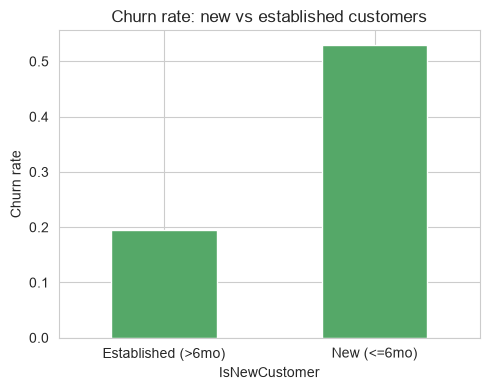

In [3]:
df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)

iv_new, _ = compute_iv(df, "IsNewCustomer", "Churn_numeric")
iv_raw, _ = compute_iv(df, "tenure", "Churn_numeric")

print(f"IsNewCustomer IV: {iv_new:.4f} ({interpret_iv(iv_new)})")
print(f"tenure (raw) IV:  {iv_raw:.4f} ({interpret_iv(iv_raw)})")

fig, ax = plt.subplots(figsize=(5, 4))
df.groupby("IsNewCustomer")["Churn_numeric"].mean().plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Churn rate")
ax.set_xticklabels(["Established (>6mo)", "New (<=6mo)"], rotation=0)
ax.set_title("Churn rate: new vs established customers")
plt.tight_layout()
plt.show()

**Verdict:** `IsNewCustomer` (IV = 0.4369, strong on its own) is still
meaningfully weaker than raw `tenure` (IV = 0.7596) — expected, since
collapsing a continuous column into two buckets always loses information.
Since `tenure` is being kept as a raw feature regardless, `IsNewCustomer`
doesn't add signal a model doesn't already have. **Reject** as a model
feature — though the `tenure<=6` threshold is worth keeping in mind for
non-modeling use, e.g. a simple ops rule ("flag anyone under 6 months")
that's more directly actionable than a raw tenure number. That's a
reporting argument, not a modeling one, so it doesn't belong in this
decision.

### Feature 3 — `ContractCommitmentMonths`

Recode `Contract` as an ordinal number (`0 / 12 / 24`) instead of three
unordered categories.

**Expected result, stated before running:** IV will likely come out
*identical* to raw `Contract`. Relabeling three categories as numbers
doesn't change which customers fall in which bin, so IV — which measures
bin separation — mathematically cannot see a difference. That's not a
failed test; it means IV is the wrong tool to judge this particular
feature. Its actual purpose (giving a linear model one ordinal number
instead of unordered one-hot columns) is something IV was never designed
to detect.

In [4]:
contract_map = {"Month-to-month": 0, "One year": 12, "Two year": 24}
df["ContractCommitmentMonths"] = df["Contract"].map(contract_map)

iv_new, _ = compute_iv(df, "ContractCommitmentMonths", "Churn_numeric")
iv_raw, _ = compute_iv(df, "Contract", "Churn_numeric")

print(f"ContractCommitmentMonths IV: {iv_new:.4f} ({interpret_iv(iv_new)})")
print(f"Contract (raw) IV:           {iv_raw:.4f} ({interpret_iv(iv_raw)})")
print(f"\nIdentical, as predicted: {np.isclose(iv_new, iv_raw)}")

ContractCommitmentMonths IV: 1.2341 (suspiciously strong -- check leakage)
Contract (raw) IV:           1.2341 (suspiciously strong -- check leakage)

Identical, as predicted: True


**Verdict:** Confirmed — `ContractCommitmentMonths` and raw `Contract`
both score exactly 1.2341, matching the prediction, since relabeling
three unordered categories as numbers can't change which customers fall
in which bin. **Keep**, on the structural reasoning (ordinality for
models that can use it), not on IV.

Separate note worth writing down: `Contract`'s raw IV (1.23) is the
highest in the entire table — well past the 0.5 "suspiciously strong"
line. Before Stage 6, it's worth stating *why* this isn't leakage rather
than only noting the number: month-to-month contracts carry no
cancellation penalty, which is a known, causally-explainable driver of
churn in this exact dataset — not a column secretly encoding the outcome.
"We checked and it's not leakage" only holds up under questioning if the
reasoning is written down, not just the number.

### Feature 4 — `AvgMonthlySpend`

`TotalCharges / tenure`. Edge case handled explicitly: customers with
`tenure == 0` would divide by zero — for them, their average monthly
spend so far *is* their current `MonthlyCharges` rate, since they haven't
completed a full billing cycle yet, so that's used as the fallback rather
than producing `inf` or `NaN`.

This is the candidate flagged in advance as most likely to fail — a
reasonable-sounding derivation is not evidence on its own, which is the
entire point of checking it here instead of trusting the intuition.

In [5]:
df["AvgMonthlySpend"] = np.where(df["tenure"] > 0,
                                  df["TotalCharges"] / df["tenure"],
                                  df["MonthlyCharges"])

iv_new, _ = compute_iv(df, "AvgMonthlySpend", "Churn_numeric")
iv_total, _ = compute_iv(df, "TotalCharges", "Churn_numeric")
iv_monthly, _ = compute_iv(df, "MonthlyCharges", "Churn_numeric")

print(f"AvgMonthlySpend IV: {iv_new:.4f} ({interpret_iv(iv_new)})")
print(f"TotalCharges (raw) IV:   {iv_total:.4f} ({interpret_iv(iv_total)})")
print(f"MonthlyCharges (raw) IV: {iv_monthly:.4f} ({interpret_iv(iv_monthly)})")

AvgMonthlySpend IV: 0.2846 (medium)
TotalCharges (raw) IV:   0.2952 (medium)
MonthlyCharges (raw) IV: 0.2985 (medium)


**Verdict:** `AvgMonthlySpend` (IV = 0.2846) comes in lower than *both*
`TotalCharges` (0.2952) and `MonthlyCharges` (0.2985) — exactly the
rejection condition flagged in advance. Averaging doesn't add anything
over having the two raw numbers separately. **Reject** — this is the
predicted outcome, and the discipline held: the derivation sounded
reasonable and still didn't survive its own test.

### Summary — every candidate against its source, side by side

In [6]:
all_features = ["tenure", "Contract", "TotalCharges", "MonthlyCharges"] + addon_cols + \
    ["TotalAddOnServices", "IsNewCustomer", "ContractCommitmentMonths", "AvgMonthlySpend"]

summary = iv_summary(df, all_features, "Churn_numeric")
summary

,feature,iv,strength
0,Contract,1.2341,suspiciously strong -- check leakage
1,ContractCommitmentMonths,1.2341,suspiciously strong -- check leakage
2,tenure,0.7596,suspiciously strong -- check leakage
3,OnlineSecurity,0.7161,suspiciously strong -- check leakage
4,TechSupport,0.6979,suspiciously strong -- check leakage
5,OnlineBackup,0.5273,suspiciously strong -- check leakage
6,DeviceProtection,0.4984,strong
7,IsNewCustomer,0.4369,strong
8,StreamingMovies,0.3802,strong
9,StreamingTV,0.3793,strong


## Decision table

| Feature | IV | vs. source | Keep / Reject | Reasoning |
|---|---|---|---|---|
| `TotalAddOnServices` | 0.1497 | Weaker than all 6 raw add-on cols (0.38–0.72) | Reject | Aggregation merges two different populations at count=0 |
| `IsNewCustomer` | 0.4369 | Weaker than raw tenure (0.7596) | Reject | Redundant — tenure already kept, adds no new signal |
| `ContractCommitmentMonths` | 1.2341 | Identical to raw Contract (predicted) | Keep | Structural (ordinality), not IV-based |
| `AvgMonthlySpend` | 0.2846 | Lower than *both* TotalCharges (0.2952) and MonthlyCharges (0.2985) | Reject | Fails its own stated rejection rule |